# 02.1 — TF-IDF on Full-Concat Scrubbed+ Text

Same plan as 04.5, but with TF-IDF + LinearSVC instead of a transformer fine-tune.

**Text input:** `Blind Assessment + Notes + Who Should Drink It + Bottom Line`,
scrubbed of countries, region aliases, cultivars, and producer-context terms.

**Purpose:** a sparse-bag-of-words counterpart to 04.5, so we can cleanly compare
classical vs transformer representations of the same scrubbed input.


In [1]:
import re
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_recall_fscore_support, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
MIN_SAMPLES_PER_CLASS = 100
TEXT_COLUMN = 'text_full_concat_scrubbed_plus'
OUTPUT_DIR = 'artifacts/origin_tfidf_fulltext_scrubbed_plus'
os.makedirs(OUTPUT_DIR, exist_ok=True)


## Scrubbing vocabulary (same 4 tiers as 04.5)

In [2]:
# Scrubbing vocabulary: countries + region aliases + cultivars + producer context
# Lifted from 04.5 so that 02.1 / 03.1 / 04.1.1 / 06.1 / 07.1 are a fair comparison.
COUNTRY_TERMS = {
    "Ethiopia": ["ethiopia", "ethiopian"],
    "Colombia": ["colombia", "colombian", "columbian"],
    "Panama": ["panama", "panamanian"],
    "Kenya": ["kenya", "kenyan"],
    "Indonesia": ["indonesia", "indonesian"],
    "Guatemala": ["guatemala", "guatemalan"],
    "Costa Rica": ["costa rica", "costa rican", "costarican"],
    "El Salvador": ["el salvador", "salvadoran", "salvadorean", "salvadorian"],
    "Rwanda": ["rwanda", "rwandan"],
    "Brazil": ["brazil", "brazilian"],
    "Honduras": ["honduras", "honduran"],
    "Peru": ["peru", "peruvian"],
    "Taiwan": ["taiwan", "taiwanese"],
    "Papua New Guinea": ["papua new guinea", "papua new guinean"],
    "Nicaragua": ["nicaragua", "nicaraguan"],
    "Burundi": ["burundi", "burundian"],
    "Thailand": ["thailand", "thai"],
    "India": ["india", "indian"],
    "Mexico": ["mexico", "mexican"],
    "Tanzania": ["tanzania", "tanzanian"],
    "Yemen": ["yemen", "yemeni"],
    "Ecuador": ["ecuador", "ecuadorian"],
    "Bolivia": ["bolivia", "bolivian"],
    "Jamaica": ["jamaica", "jamaican"],
    "Uganda": ["uganda", "ugandan"],
    "Dominican Republic": ["dominican republic", "dominican"],
    "Zambia": ["zambia", "zambian"],
    "China": ["china", "chinese"],
    "Vietnam": ["vietnam", "vietnamese"],
    "Philippines": ["philippines", "philippine", "filipino"],
    "Malaysia": ["malaysia", "malaysian"],
    "Laos": ["laos", "laotian"],
    "Zimbabwe": ["zimbabwe", "zimbabwean"],
    "Haiti": ["haiti", "haitian"],
    "Puerto Rico": ["puerto rico", "puerto rican", "puertorican"],
    "Nepal": ["nepal", "nepalese", "nepali"],
    "Myanmar": ["myanmar", "burmese"],
    "Cameroon": ["cameroon", "cameroonian"],
    "Australia": ["australia", "australian"],
    "South Africa": ["south africa", "south african"],
    "Malawi": ["malawi", "malawian"],
    "Venezuela": ["venezuela", "venezuelan", "merida state", "mocoties valley"],
    "Timor-Leste": ["east timor", "timor leste", "timorese"],
    "DR Congo": ["democratic republic of the congo", "dr congo", "congo", "congolese"],
    "United Kingdom": ["united kingdom", "british", "pitcairn island", "saint helena", "st helena", "sandy bay valley"],
    "United States": [
        "usa", "united states", "american",
        "hawaii", "hawai'i", "hawaiian", "hawaii island",
        "big island", "kona", "puna district", "holualoa", "oahu", "maui", "kauai",
        "ka u", "ka'u", "kau",
    ],
}

REGION_ALIASES = {
    "Ethiopia": ["yirgacheffe", "sidamo", "sidama", "guji", "gedeb", "gedeo", "kochere", "hambela",
                 "shakiso", "jimma", "limu", "oromia", "harrar", "kaffa", "bench maji", "bench-maji",
                 "arbegona", "bensa"],
    "Colombia": ["huila", "cauca", "narino", "tolima", "quindio", "caldas", "risaralda", "antioquia",
                 "cundinamarca", "santander", "pitalito", "acevedo", "planadas", "gaitania", "piendamo",
                 "caicedonia", "san agustin", "armenia"],
    "Panama": ["boquete", "chiriqui", "volcan", "jaramillo", "alto quiel", "paso ancho",
               "piedra candela", "canas verdes", "silla del pando", "renacimiento"],
    "Kenya": ["nyeri", "kirinyaga", "kiambu", "embu", "muranga", "murang'a", "thika", "ruiru",
              "mathira", "meru", "nakuru", "gichugu", "karatina"],
    "Indonesia": ["sumatra", "aceh", "gayo", "lintong", "mandheling", "sidikalang", "toraja",
                  "sulawesi", "java", "bali", "kintamani", "flores", "kerinci"],
    "Guatemala": ["huehuetenango", "antigua", "acatenango", "fraijanes", "coban", "atitlan",
                  "chimaltenango", "quiche", "solola", "palencia", "sacatepequez", "san marcos",
                  "hoja blanca", "cuilco"],
    "Costa Rica": ["tarrazu", "central valley", "west valley", "tres rios", "naranjo", "dota",
                   "poas", "alajuela", "brunca", "turrialba", "coto brus", "chirripo"],
    "El Salvador": ["ahuachapan", "chalatenango", "apaneca", "ilamatepec", "santa ana",
                    "el boqueron", "quetzaltepec", "juayua", "ataco"],
    "Rwanda": ["gakenke", "nyamasheke", "karongi", "huye", "nyamagabe", "rulindo", "gikongoro",
               "lake kivu"],
    "Brazil": ["cerrado", "mogiana", "minas gerais", "mantiqueira", "sul de minas",
               "chapada diamantina", "carmo de minas"],
    "Honduras": ["marcala", "copan", "ocotepeque", "comayagua", "intibuca", "santa barbara",
                 "el paraiso", "capucas"],
    "Peru": ["cajamarca", "jaen", "san ignacio", "chanchamayo", "cusco", "villa rica", "oxapampa",
             "junin", "puno"],
    "Taiwan": ["alishan", "yunlin", "chiayi", "chia yi", "nantou", "taichung", "pingtung"],
    "Papua New Guinea": ["wahgi valley", "western highlands", "eastern highlands", "jiwaka",
                         "kainantu", "okapa"],
    "Nicaragua": ["jinotega", "matagalpa", "nueva segovia", "madriz", "ocotal", "dipilto"],
    "Burundi": ["kayanza", "ngozi", "muramvya", "muyinga", "bururi"],
    "Thailand": ["chiang rai", "doi chang", "doi pangkhon", "chiang mai", "nan province"],
    "India": ["coorg", "chikmagalur", "karnataka", "bababudangiri", "nilgiris"],
    "Mexico": ["chiapas", "oaxaca", "veracruz", "coatepec", "pluma hidalgo"],
    "Tanzania": ["mbeya", "ruvuma", "ngorongoro", "arusha", "kilimanjaro", "mbozi"],
    "Yemen": ["haraaz", "haraz", "sanaa", "bani matar", "hayma"],
    "Ecuador": ["loja", "pichincha", "imbabura", "zamora", "chimborazo", "saraguro"],
    "Bolivia": ["caranavi", "yungas", "la paz"],
    "Jamaica": ["blue mountain", "blue mountains"],
    "Uganda": ["rwenzori", "bugisu", "sipi falls"],
    "Vietnam": ["lam dong", "quang tri", "dalat", "cau dat"],
    "Philippines": ["benguet", "bukidnon", "davao"],
    "China": ["yunnan", "baoshan", "puer", "pu'er", "lincong"],
    "Puerto Rico": ["utuado", "yauco", "adjuntas"],
    "Venezuela": ["mocoties valley", "merida state"],
    "Malawi": ["malawi"],
}

REGION_ONLY_TERMS = [
    "central america", "south america", "latin america",
    "east africa", "central africa", "west africa", "africa",
    "asia", "the americas", "americas",
    "central and south america", "south and central america",
    "east and central africa", "various africa growing regions",
]

CULTIVAR_TERMS = [
    "sl28", "sl-28", "sl 28", "sl34", "sl-34", "sl 34",
    "ruiru 11", "ruiru-11", "batian", "k7",
    "gesha", "geisha",
    "pacamara", "pache", "villa sarchi",
    "bourbon", "pink bourbon", "yellow bourbon", "red bourbon",
    "caturra", "catuai", "catuai vermelho", "catuai amarelo",
    "typica", "mundo novo",
    "maragogipe", "maragogype", "maracaturra",
    "castillo", "colombia variety", "variedad colombia", "tabi",
    "heirloom", "ethiopian heirloom",
    "tim tim", "s795", "ateng",
    "catimor", "sarchimor", "icatu", "obata",
]

PRODUCER_CONTEXT_TERMS = [
    "finca", "hacienda", "beneficio",
    "cup of excellence",
    "washing station", "wet mill",
    "best of panama",
]

all_scrub_terms = []
for v in COUNTRY_TERMS.values():    all_scrub_terms.extend(v)
for v in REGION_ALIASES.values():   all_scrub_terms.extend(v)
all_scrub_terms.extend(REGION_ONLY_TERMS)
all_scrub_terms.extend(CULTIVAR_TERMS)
all_scrub_terms.extend(PRODUCER_CONTEXT_TERMS)
all_scrub_terms = sorted(set(all_scrub_terms), key=len, reverse=True)
print(f'Loaded {len(all_scrub_terms)} scrub terms')

SCRUB_PATTERN = re.compile(
    r'\b(' + '|'.join(re.escape(t) for t in all_scrub_terms) + r')\b',
    flags=re.IGNORECASE,
)

def scrub(text):
    if not isinstance(text, str) or not text:
        return ''
    return SCRUB_PATTERN.sub(' [ORIGIN] ', text)


Loaded 403 scrub terms


## Build `text_full_concat_scrubbed_plus`

In [3]:
# Concat Blind Assessment + Notes + Who Should Drink It + Bottom Line, then scrub
def minimal_raw_text(text):
    text = '' if pd.isna(text) else str(text)
    return re.sub(r'\s+', ' ', text).strip().lower()

def normalize_text_keep_brackets(text):
    text = minimal_raw_text(text)
    text = re.sub(r'[^a-z0-9\s\[\]]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

EXTRA_TEXT_COLS = ['Blind Assessment', 'Notes', 'Who Should Drink It', 'Bottom Line']

def concat_and_scrub(row):
    pieces = []
    for col in EXTRA_TEXT_COLS:
        v = row[col]
        if pd.notna(v) and str(v).strip():
            raw = minimal_raw_text(v)
            scrubbed = scrub(raw)
            cleaned = normalize_text_keep_brackets(scrubbed)
            pieces.append(cleaned)
    return ' '.join(p for p in pieces if p)

df = pd.read_csv('Data/final_coffee_reviews.csv')
df['text_full_concat_scrubbed_plus'] = df.apply(concat_and_scrub, axis=1)
df['text_raw_minimal'] = df['Blind Assessment'].fillna('').map(minimal_raw_text)
df['origin_country'] = df['Country'].astype('string').str.strip().replace('', pd.NA)

work = df[(df['text_raw_minimal'].str.len() >= 30) & (df['origin_country'].notna())].copy()
counts = work['origin_country'].value_counts()
valid_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index
work = work[work['origin_country'].isin(valid_classes)].copy().reset_index(drop=True)

# Leakage audit
def contains_own_country(row):
    t = row['text_full_concat_scrubbed_plus'].lower()
    c = str(row['origin_country']).lower()
    return c in t if c and t else False
work['leaks_country'] = work.apply(contains_own_country, axis=1)
leak_rate = float(work['leaks_country'].mean())

print(f'Rows: {len(work)} | Classes: {work["origin_country"].nunique()}')
print(f'Avg scrubbed+ text length (chars): {int(work["text_full_concat_scrubbed_plus"].str.len().mean())}')
print(f'Country-name leakage: {leak_rate:.1%}  (target: <2%)')


Rows: 6820 | Classes: 15
Avg scrubbed+ text length (chars): 875
Country-name leakage: 0.8%  (target: <2%)


## 70/15/15 stratified split

In [4]:
# Same 70/15/15 stratified split as the rest of the pipeline
y = work['origin_country']
row_idx = work.index
train_idx, temp_idx, y_train, y_temp = train_test_split(
    row_idx, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)
print('Train/Val/Test:', len(train_idx), len(val_idx), len(test_idx))


Train/Val/Test: 4774 1023 1023


## Fit TF-IDF + a small model benchmark on the scrubbed full-concat column

In [5]:
X_train = work.loc[train_idx, TEXT_COLUMN].fillna('')
X_val   = work.loc[val_idx,   TEXT_COLUMN].fillna('')
X_test  = work.loc[test_idx,  TEXT_COLUMN].fillna('')

def evaluate(name, model):
    y_val_pred  = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    val_p, val_r, val_f1, _   = precision_recall_fscore_support(y_val,  y_val_pred,  average='macro', zero_division=0)
    test_p, test_r, test_f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='macro', zero_division=0)
    return {
        'model': name,
        'val_accuracy':          accuracy_score(y_val,  y_val_pred),
        'val_balanced_accuracy': balanced_accuracy_score(y_val,  y_val_pred),
        'val_f1_macro':          val_f1,
        'test_accuracy':          accuracy_score(y_test, y_test_pred),
        'test_balanced_accuracy': balanced_accuracy_score(y_test, y_test_pred),
        'test_f1_macro':          test_f1,
        'y_test_pred': y_test_pred,
    }

benchmark_specs = [
    ('Linear SVM (word 1-2gram, C=1)',
     Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.90, sublinear_tf=True)),
               ('clf', LinearSVC(C=1.0, class_weight='balanced', dual='auto', max_iter=10000, random_state=RANDOM_STATE))])),
    ('Linear SVM (word 1-2gram, C=5)',
     Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.90, sublinear_tf=True)),
               ('clf', LinearSVC(C=5.0, class_weight='balanced', dual='auto', max_iter=10000, random_state=RANDOM_STATE))])),
    ('Logistic Regression (word 1-2gram, C=1)',
     Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.90, sublinear_tf=True)),
               ('clf', LogisticRegression(C=1.0, max_iter=5000, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE))])),
    ('Linear SVM (char_wb 3-5gram, C=1)',
     Pipeline([('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=3, max_df=0.90, sublinear_tf=True)),
               ('clf', LinearSVC(C=1.0, class_weight='balanced', dual='auto', max_iter=10000, random_state=RANDOM_STATE))])),
]

results = []
best_score = -1
best_name = None
best_pred = None
for name, pipe in benchmark_specs:
    pipe.fit(X_train, y_train)
    r = evaluate(name, pipe)
    print(f"{name:50s} val F1={r['val_f1_macro']:.4f}  test F1={r['test_f1_macro']:.4f}")
    if r['val_f1_macro'] > best_score:
        best_score = r['val_f1_macro']
        best_name = name
        best_pred = r['y_test_pred']
    r.pop('y_test_pred')
    results.append(r)

results_df = pd.DataFrame(results).sort_values('val_f1_macro', ascending=False).reset_index(drop=True)
print()
print('Best (by val F1):', best_name)
results_df


Linear SVM (word 1-2gram, C=1)                     val F1=0.6068  test F1=0.6405
Linear SVM (word 1-2gram, C=5)                     val F1=0.6178  test F1=0.6264
Logistic Regression (word 1-2gram, C=1)            val F1=0.5501  test F1=0.5764
Linear SVM (char_wb 3-5gram, C=1)                  val F1=0.5867  test F1=0.6367

Best (by val F1): Linear SVM (word 1-2gram, C=5)


,model,val_accuracy,val_balanced_accuracy,val_f1_macro,test_accuracy,test_balanced_accuracy,test_f1_macro
0,"Linear SVM (word 1-2gram, C=5)",0.726295,0.585060,0.617785,0.745846,0.608401,0.626368
1,"Linear SVM (word 1-2gram, C=1)",0.724340,0.593414,0.606785,0.753666,0.637394,0.640538
2,"Linear SVM (char_wb 3-5gram, C=1)",0.710655,0.588676,0.586739,0.749756,0.644562,0.636733
3,"Logistic Regression (word 1-2gram, C=1)",0.667644,0.555230,0.550106,0.684262,0.582382,0.576355


## Per-class report and confusion matrix for the winning model

Winner: Linear SVM (word 1-2gram, C=5)
  test Macro-F1: 0.6264
  test Balanced Acc: 0.6084
  test Accuracy: 0.7458

               precision    recall  f1-score   support

     Ethiopia      0.862     0.900     0.881       299
     Colombia      0.630     0.689     0.658       148
        Kenya      0.897     0.914     0.906       105
    Guatemala      0.622     0.607     0.614        84
    Indonesia      0.743     0.765     0.754        68
   Costa Rica      0.544     0.554     0.549        56
       Panama      0.780     0.868     0.821        53
United States      0.870     0.889     0.879        45
  El Salvador      0.512     0.583     0.545        36
       Brazil      0.727     0.533     0.615        30
       Rwanda      0.900     0.667     0.766        27
         Peru      0.400     0.200     0.267        20
    Nicaragua      0.412     0.368     0.389        19
     Honduras      0.538     0.389     0.452        18
       Mexico      0.600     0.200     0.300        15

  

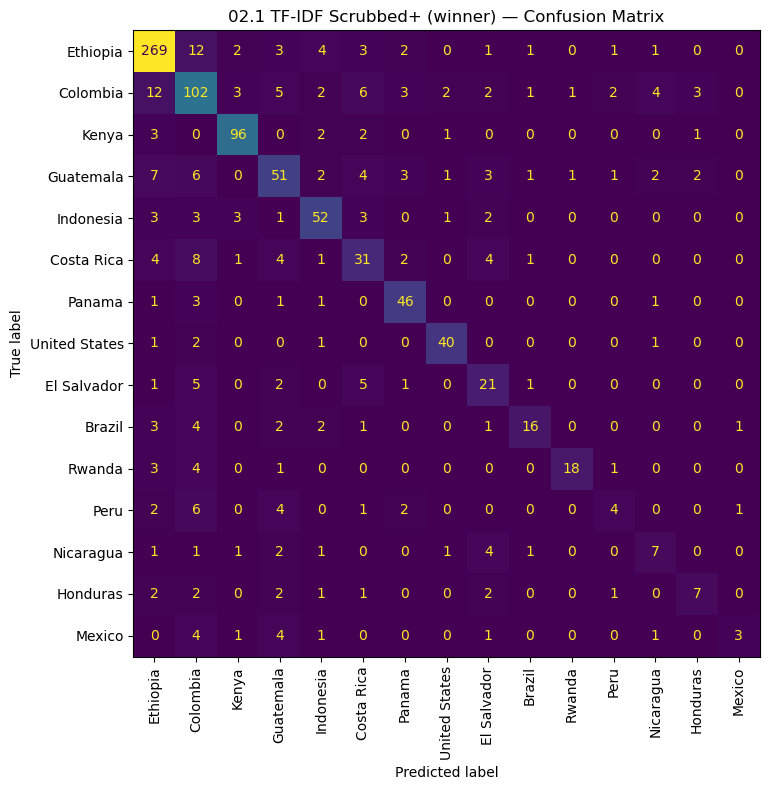

In [6]:
class_order = work['origin_country'].value_counts().index.tolist()
print(f'Winner: {best_name}')
print(f'  test Macro-F1: {f1_score(y_test, best_pred, average="macro", zero_division=0):.4f}')
print(f'  test Balanced Acc: {balanced_accuracy_score(y_test, best_pred):.4f}')
print(f'  test Accuracy: {accuracy_score(y_test, best_pred):.4f}')
print()
print(classification_report(y_test, best_pred, labels=class_order, zero_division=0, digits=3))

cm = confusion_matrix(y_test, best_pred, labels=class_order)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order).plot(
    ax=ax, xticks_rotation=90, colorbar=False,
)
plt.title('02.1 TF-IDF Scrubbed+ (winner) — Confusion Matrix')
plt.tight_layout()
plt.show()


## Save results

In [7]:
with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
    json.dump({
        'notebook': '02.1_TFIDF_FullText_Scrubbed_Plus',
        'text_column': TEXT_COLUMN,
        'text_columns_used': EXTRA_TEXT_COLS,
        'scrub_tiers': ['countries_and_adjectivals', 'coffee_region_aliases', 'cultivars', 'producer_context_terms'],
        'num_scrub_terms': len(all_scrub_terms),
        'post_scrub_leakage_rate': leak_rate,
        'winner': best_name,
        'all_models': results,
    }, f, indent=2, default=float)
print('Saved', os.path.join(OUTPUT_DIR, 'results.json'))


Saved artifacts/origin_tfidf_fulltext_scrubbed_plus\results.json
